# B2B Customer Behavioral Anomaly Detection
Full pipeline via modular `src/anomaly_detection/` package.
All logic lives in the modules — this notebook is the orchestration layer.

---
## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Ensure src/ is on path when running without pip install
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt

from anomaly_detection import load_config
from anomaly_detection.data.loader import load_raw, clean
from anomaly_detection.features.engineer import (
    FEATURE_NAMES, build_customer_features, BehavioralFeatureTransformer,
)
from anomaly_detection.models.detector import AnomalyDetectorSuite
from anomaly_detection.evaluation.synthetic import inject_anomalies
from anomaly_detection.evaluation.hitl import simulate_hitl_review
from anomaly_detection.evaluation.psi import monitor_psi
from anomaly_detection.visualization import plots
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

cfg = load_config(ROOT / "config" / "config.yaml")
print("Config loaded:", list(cfg.keys()))


Config loaded: ['data', 'features', 'models', 'evaluation', 'mlflow']


---
## 1. Data Loading & Cleaning

In [2]:
df_raw = load_raw(ROOT / cfg["data"]["path"], sheets=cfg["data"]["sheets"])
print(f"Raw shape: {df_raw.shape}")

df = clean(df_raw)
print(f"Cleaned: {df.shape[0]:,} rows | {df['Customer ID'].nunique():,} customers")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head(3)


Raw shape: (1067371, 8)
Cleaned: 779,425 rows | 5,878 customers
Date range: 2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


---
## 2. Feature Engineering
11 behavioral features per customer: RFM + variability + timing + revenue trend.

In [3]:
feat_df = build_customer_features(
    df, min_slope_months=cfg["features"]["min_slope_months"]
)
print(f"Feature matrix: {feat_df.shape}  |  NaNs: {feat_df[FEATURE_NAMES].isna().sum().sum()}")
feat_df[FEATURE_NAMES].describe().round(2)


Feature matrix: (5878, 11)  |  NaNs: 0


,total_orders,total_revenue,mean_order_value,cv_order_value,mean_order_qty,cv_order_qty,mean_basket_size,recency_days,iod_mean,iod_std,revenue_slope
count,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00
mean,6.29,2955.90,384.61,0.37,247.17,0.44,21.02,201.33,93.31,32.74,-0.79
std,13.01,14440.85,1214.22,0.34,1424.37,0.39,17.84,209.34,84.61,45.65,115.31
min,1.00,2.95,2.95,0.00,1.00,0.00,1.00,1.00,0.00,0.00,-1557.34
25%,1.00,342.28,176.57,0.00,90.83,0.00,9.61,26.00,50.03,0.00,-1.32
50%,3.00,867.74,278.41,0.35,153.00,0.44,17.00,96.00,71.63,13.28,0.00
75%,7.00,2248.31,414.25,0.58,256.00,0.70,26.84,380.00,100.75,51.94,0.00
max,398.00,580987.04,84236.25,3.45,87167.00,3.46,298.82,739.00,714.00,350.50,5930.88


In [4]:
feat_df.head(5)

,total_orders,total_revenue,mean_order_value,cv_order_value,mean_order_qty,cv_order_qty,mean_basket_size,recency_days,iod_mean,iod_std,revenue_slope
Customer ID,,,,,,,,,,,
12346,12,77556.46,6463.038333,3.445938,6190.416667,3.460541,2.833333,326,35.909091,62.382186,5930.879982
12347,8,4921.53,615.191250,0.513293,370.875000,0.457984,27.750000,2,57.000000,17.623037,2.403495
12348,5,2019.40,403.880000,0.693020,542.800000,0.781153,9.400000,75,90.500000,49.972492,-7.532850
12349,4,4428.69,1107.172500,0.602451,406.000000,0.684812,43.750000,19,189.666667,152.718332,57.740983
12350,1,334.40,334.400000,0.000000,197.000000,0.000000,17.000000,310,71.627778,0.000000,0.000000


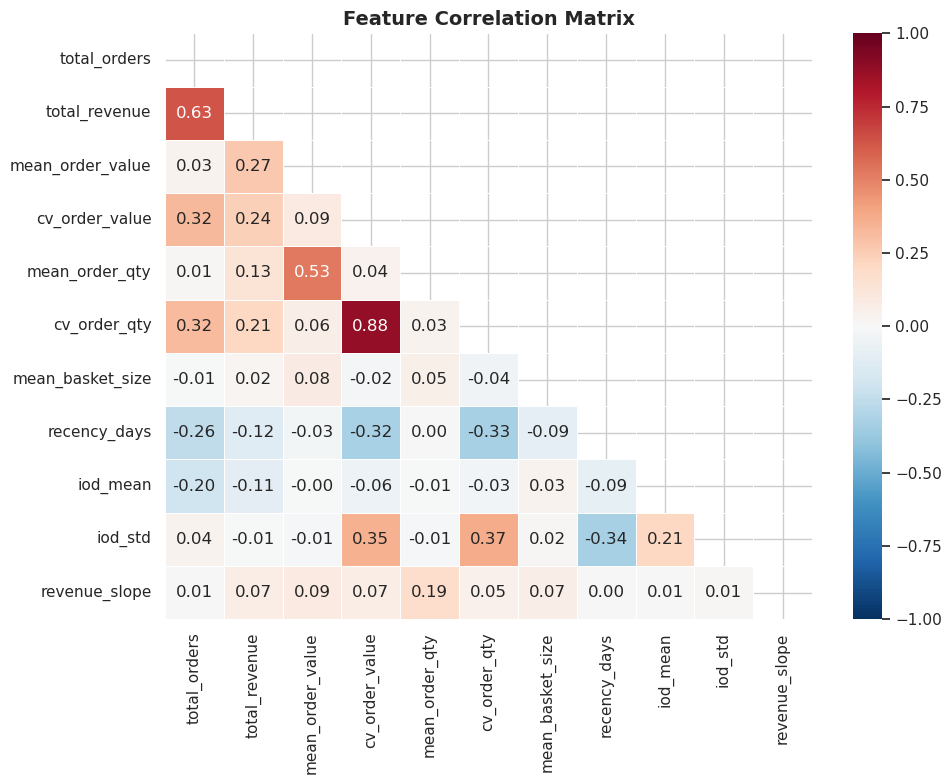

In [5]:
fig = plots.plot_correlation_heatmap(feat_df.reset_index(), FEATURE_NAMES)
plt.show()


---
## 3. Synthetic Anomaly Injection
Inject known outliers → measure **recall** (can the model find what we planted?).

In [6]:
eval_cfg = cfg["evaluation"]
X_raw = feat_df[FEATURE_NAMES].values

injection = inject_anomalies(
    X_raw,
    frac=eval_cfg["synthetic_frac"],
    injection_types=eval_cfg["injection_types"],
    random_state=cfg["models"]["random_state"],
)

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
X_inj_scaled = scaler.fit_transform(imputer.fit_transform(injection.X_injected))

import pandas as pd
print(f"Injected {injection.n_injected} anomalies ({eval_cfg['synthetic_frac']:.0%} of {len(X_raw)})")
pd.Series(injection.injection_types).value_counts().rename("count").to_frame()


Injected 293 anomalies (5% of 5878)


,count
timing_irregular,85
frequency_drop,80
volume_spike,73
revenue_collapse,55


---
## 4. Model Training & Evaluation
Isolation Forest · LOF · HBOS · Score Ensemble

In [7]:
suite  = AnomalyDetectorSuite(cfg["models"], mlflow_cfg=cfg["mlflow"])
result = suite.fit_predict(X_inj_scaled, injection.labels_true)

import pandas as pd
summary_df = pd.DataFrame(result.summary()).T.reset_index().rename(columns={"index": "Model"})
summary_df = summary_df.round(4)
print(f"\nBest model: {result.best_model_name}  (F1={result.best.f1:.3f})")
summary_df


2026/04/03 21:20:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 21:20:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 21:21:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec


Best model: LOF  (F1=0.174)


,Model,recall,precision,f1,auc
0,IsolationForest,0.1331,0.1327,0.1329,0.1033
1,LOF,0.1741,0.1735,0.1738,0.1231
2,HBOS,0.0956,0.0952,0.0954,0.0679
3,Ensemble,0.1399,0.1395,0.1397,0.0972


---
## 5. Visualizations

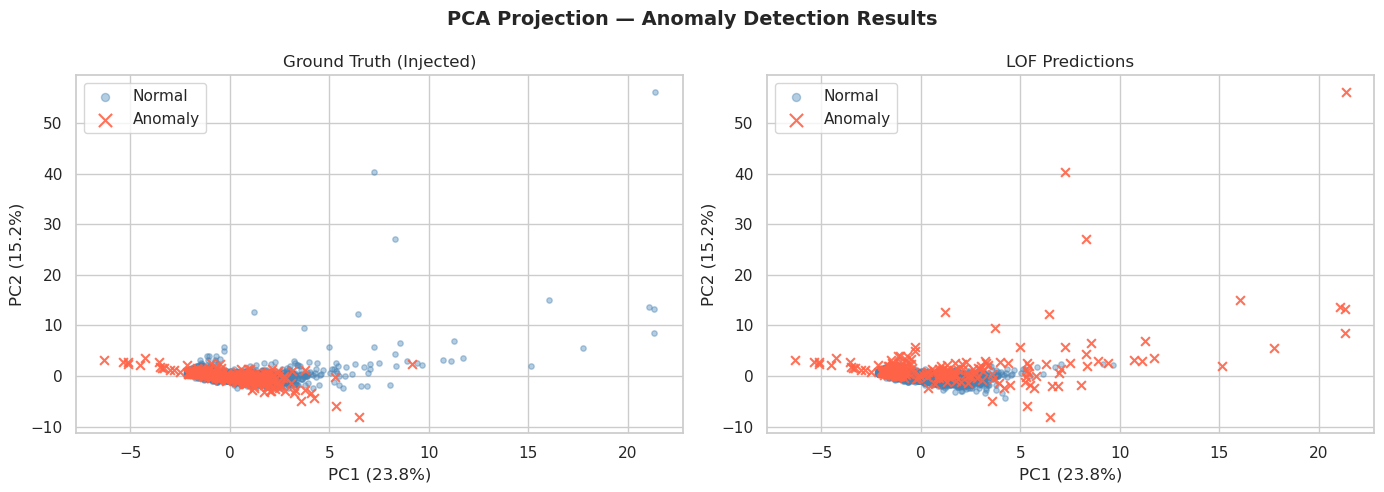

In [8]:
fig = plots.plot_pca_scatter(
    X_inj_scaled, injection.labels_true,
    result.best.labels, result.best_model_name
)
plt.show()


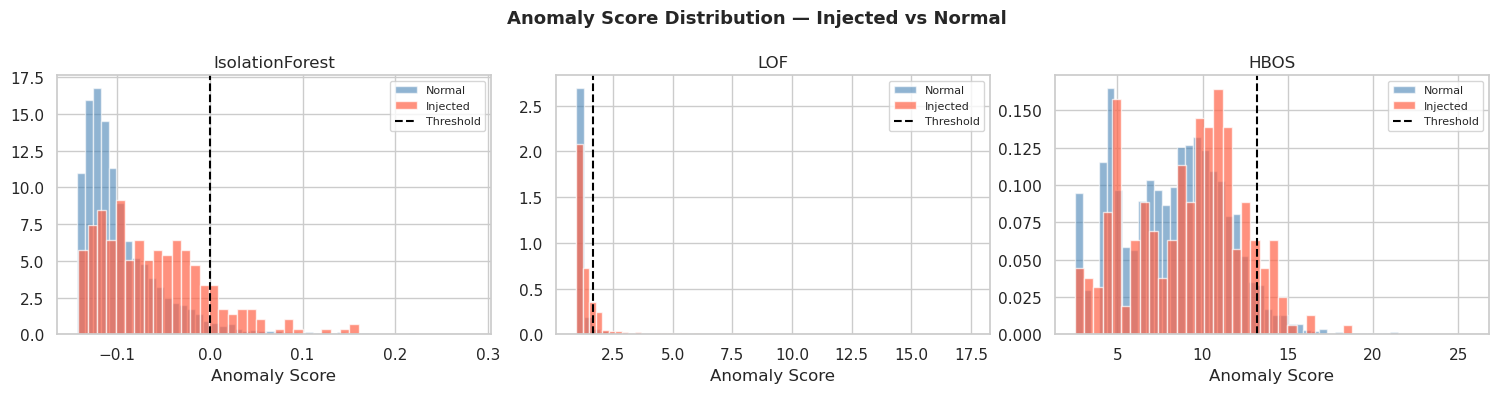

In [9]:
fig = plots.plot_score_distributions(
    result.models, injection.labels_true, cfg["models"]["contamination"]
)
plt.show()


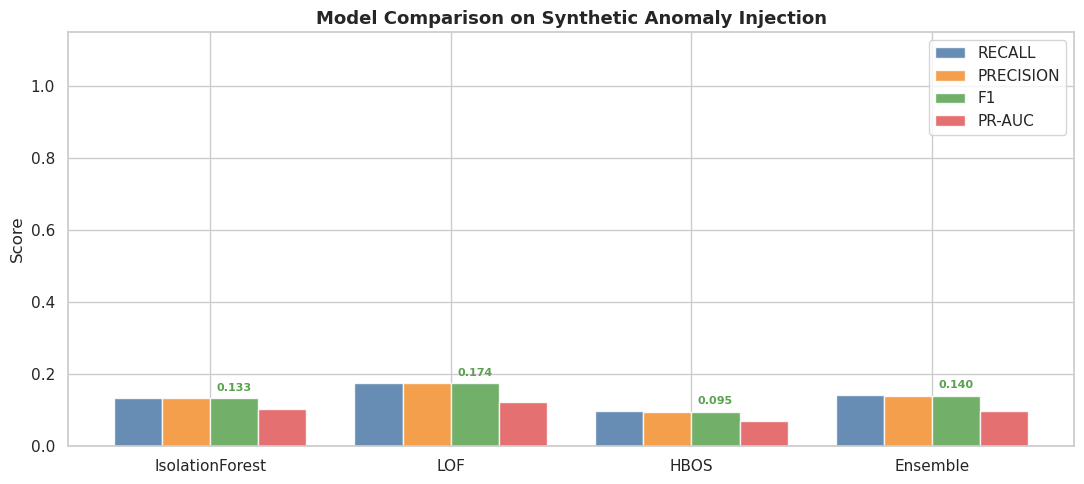

In [10]:
fig = plots.plot_model_comparison(result.summary())
plt.show()


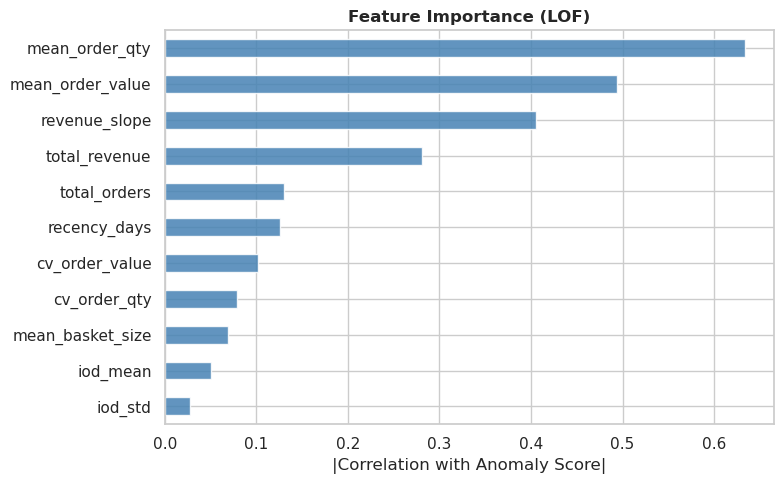

In [11]:
fig = plots.plot_feature_importance(
    X_inj_scaled, result.best.scores, FEATURE_NAMES, result.best_model_name
)
plt.show()


---
## 6. HITL Precision Simulation
12-week control-team review loop accumulating ground truth.

In [12]:
flagged_idx = np.where(result.best.labels == 1)[0]
hitl = simulate_hitl_review(
    flagged_idx,
    injection.labels_true,
    weekly_sample=eval_cfg["hitl_weekly_sample"],
    n_weeks=eval_cfg["hitl_n_weeks"],
    random_state=cfg["models"]["random_state"],
)
print(f"Final HITL precision: {hitl.final_precision:.3f}  (reviewed {hitl.total_reviewed} records)")
hitl.weekly


Final HITL precision: 0.179  (reviewed 240 records)


,week,cumulative_precision,tp,fp
0,1,0.300000,6,14
1,2,0.300000,12,28
2,3,0.250000,15,45
3,4,0.237500,19,61
4,5,0.240000,24,76
5,6,0.216667,26,94
6,7,0.214286,30,110
7,8,0.206250,33,127
8,9,0.194444,35,145
9,10,0.185000,37,163


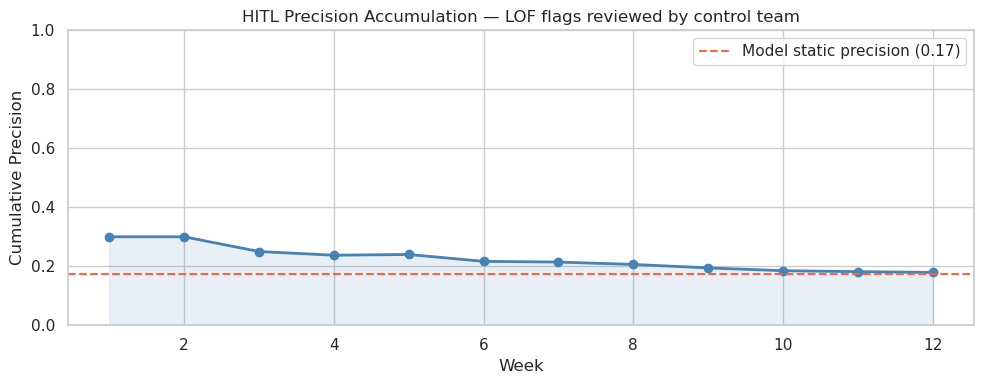

In [13]:
fig = plots.plot_hitl_precision(hitl.weekly, result.best.precision, result.best_model_name)
plt.show()


---
## 7. PSI Distribution Monitoring
Year-over-year feature drift — flags features that need retraining attention.

In [14]:
df_09 = clean(load_raw(ROOT / cfg["data"]["path"], sheets=[cfg["data"]["sheets"][0]]))
df_10 = clean(load_raw(ROOT / cfg["data"]["path"], sheets=[cfg["data"]["sheets"][1]]))

feat_09 = build_customer_features(df_09)
feat_10 = build_customer_features(df_10)

psi_df = monitor_psi(
    feat_09, feat_10, FEATURE_NAMES,
    n_bins=eval_cfg["psi_n_bins"],
    slight_threshold=eval_cfg["psi_slight_threshold"],
    significant_threshold=eval_cfg["psi_significant_threshold"],
)
print(psi_df.to_string(index=False))


         feature  psi status
    total_orders  0.0 STABLE
   total_revenue  0.0 STABLE
mean_order_value  0.0 STABLE
  cv_order_value  0.0 STABLE
  mean_order_qty  0.0 STABLE
    cv_order_qty  0.0 STABLE
mean_basket_size  0.0 STABLE
    recency_days  0.0 STABLE
        iod_mean  0.0 STABLE
         iod_std  0.0 STABLE
   revenue_slope  0.0 STABLE


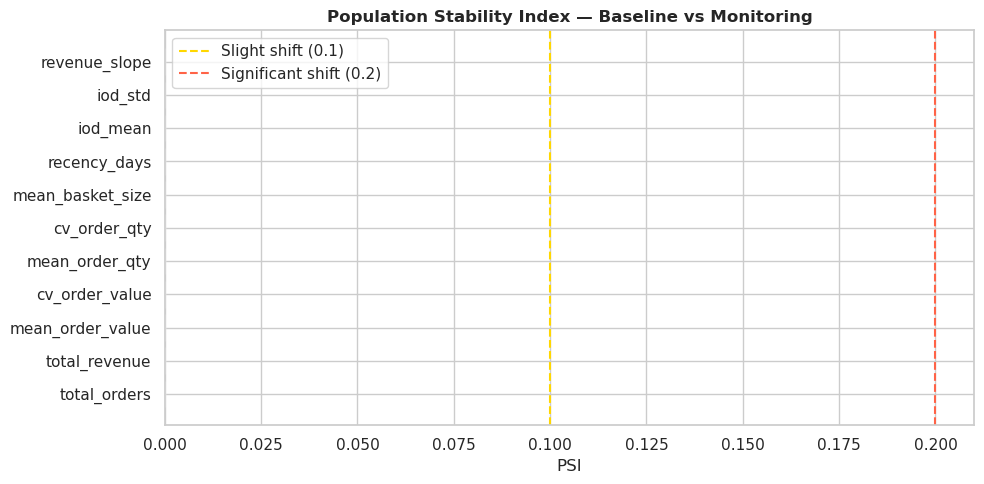

In [15]:
fig = plots.plot_psi(psi_df)
plt.show()


---
## 8. Final Report

In [16]:
shifted = psi_df[psi_df["status"] != "STABLE"]["feature"].tolist()
print("=" * 50)
print("FINAL REPORT")
print("=" * 50)
print(f"Customers analysed    : {len(feat_df):,}")
print(f"Synthetic anomalies   : {injection.n_injected} ({eval_cfg['synthetic_frac']:.0%})")
print(f"Best model            : {result.best_model_name}")
print(f"  Recall              : {result.best.recall:.3f}")
print(f"  Precision           : {result.best.precision:.3f}")
print(f"  F1                  : {result.best.f1:.3f}")
print(f"  PR-AUC             : {result.best.auc:.3f}")
print(f"HITL precision (wk{eval_cfg['hitl_n_weeks']:>2}) : {hitl.final_precision:.3f}")
print(f"PSI-flagged features  : {shifted if shifted else 'None'}")


FINAL REPORT
Customers analysed    : 5,878
Synthetic anomalies   : 293 (5%)
Best model            : LOF
  Recall              : 0.174
  Precision           : 0.173
  F1                  : 0.174
  PR-AUC             : 0.123
HITL precision (wk12) : 0.179
PSI-flagged features  : None
